<p style="background-color:black; font-family:calibri; color:pink; font-size:170%; text-align:center; border-radius:15px 50px;">Capstone Project 
    |E-commerce_Customer_Segmentation_and_Prediction</p>

This project focuses on analyzing e-commerce customer transaction data to segment customers based on their purchasing behavior and predict high-value customers using machine learning techniques.

<div style="border-radius:10px; padding: 15px; background-color: black; font-size:150%; text-align:left">
<h3 align="left"><font color=pink>Introduction:</font></h3>
    

In the growing e-commerce industry, understanding customer behavior is essential for improving business performance. Customer segmentation helps businesses identify different customer groups and design targeted marketing strategies. The system predicts customer segments based on purchasing patterns derived from past transaction data

<div style="border-radius:10px; padding: 15px; background-color: black; font-size:110%; text-align:left">

<h3 align="left"><font color=pink>Problem:</font></h3>

## Problem Statement

The objective of this project is:
- Segment customers using RFM analysis
- Identify high-value, medium-value, and low-value customers
- Predict the customer segment using supervised machine learning models
- Support targeted marketing strategies

<a id="contents_table"></a>

<div style="background:black; padding:22px; border-radius:10px; font-size:115%; line-height:1.7; border-left:6px solid #22d3ee;">

<h3 style="color:pink; margin-bottom:12px;">Project Workflow</h3>

<ul style="color:#e2e8f0;">
    <li><a href="#import">Step 1 | Import Libraries</a></li>
    <li><a href="#read">Step 2 | Read Dataset</a></li>
    <li><a href="#overview">Step 3 | Dataset Overview</a></li>
    <li><a href="#preprocessing">Step 4 | Data Preprocessing</a></li>
    <li><a href="#eda">Step 5 | Exploratory Data Analysis</a></li>
    <li><a href="#scaling">Step 6 | Feature Scaling</a></li>
    <li><a href="#rf">Step 7 | Random Forest</a></li>
    <li><a href="#lr">Step 8 | Logistic Regression</a></li>
    <li><a href="#comparison">Step 9 | Model Comparison</a></li>
    <li><a href="#conclusion">Step 10 | Conclusion</a></li>
</ul>

</div>


## Dataset Description

The dataset contains transactional data from an e-commerce platform. Each record represents a customer purchase and includes invoice details, product information, quantity, transaction date, unit price, customer ID, and country.


<h2 align="left"><font color="pink">Let's get started:</font></h2>

## Importing Required Libraries


<a id="import"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>


In [1]:
import numpy as np
import pandas as pd
import os

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder



from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import ipywidgets as widgets
from IPython.display import display, HTML
import joblib


import warnings
warnings.filterwarnings('ignore')

In [2]:
os.getcwd()

'C:\\Users\\ajoyb'

In [3]:
os.chdir(r"C:\BLA Capston Projects")

In [4]:
os.getcwd()

'C:\\BLA Capston Projects'

<a id="read"></a>
# <p style="background-color:black ; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

## load The CSV Dataset 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Data Loading


In [7]:
df = pd.read_csv(
    "capston project data.csv",
    encoding="latin1"
)

<div style="border-radius:10px; padding:15px; background-color:black; font-size:120%; text-align:left;">

<h2 align="left" style="color:pink;">Dataset Description</h2>

 <div style="border-radius:10px; padding:20px; background-color:black; border:2px solid #cccccc;">

 <h3 style="color:pink; border-bottom:2px solid pink; padding-bottom:5px;">
            Data Summary & Description
        </h3>

 <p style="color:#e5e7eb;">
            The dataset used in this project consists of transactional records from an e-commerce platform.
            Each record represents a single purchase made by a customer.
            The dataset is used to analyze customer purchasing behavior, perform customer segmentation,
            and predict high-value customers.
        </p>

<h3 style="color:#22d3ee;">Descriptive Statistics for Numerical Features</h3>

 <table border="1" cellpadding="8" cellspacing="0"
               style="border-collapse:collapse; color:#e5e7eb; width:100%;">
            <tr style="background-color:#1f2933;">
                <th>Feature</th>
                <th>Description</th>
            </tr>
            <tr>
                <td>Quantity</td>
                <td>Number of products purchased in a single transaction</td>
            </tr>
            <tr>
                <td>UnitPrice</td>
                <td>Price of a single unit of a product</td>
            </tr>
            <tr>
                <td>TotalAmount</td>
                <td>Total transaction value (Quantity &times; UnitPrice)</td>
            </tr>
            <tr>
                <td>Recency</td>
                <td>Number of days since the customer&#39;s last purchase</td>
            </tr>
            <tr>
                <td>Frequency</td>
                <td>Total number of transactions made by the customer</td>
            </tr>
            <tr>
                <td>Monetary</td>
                <td>Total amount spent by the customer</td>
            </tr>
        </table>

<br>

<h3 style="color:#22d3ee;">Variable Descriptions (E-commerce Dataset)</h3>

<table border="1" cellpadding="8" cellspacing="0"
               style="border-collapse:collapse; color:#e5e7eb; width:100%;">
            <tr style="background-color:#1f2933;">
                <th>Variable</th>
                <th>Description</th>
            </tr>
            <tr>
                <td>InvoiceNo</td>
                <td>Unique identifier assigned to each purchase transaction</td>
            </tr>
            <tr>
                <td>StockCode</td>
                <td>Unique code assigned to each product</td>
            </tr>
            <tr>
                <td>Description</td>
                <td>Name or description of the purchased product</td>
            </tr>
            <tr>
                <td>Quantity</td>
                <td>Number of units purchased in the transaction</td>
            </tr>
            <tr>
                <td>InvoiceDate</td>
                <td>Date and time when the transaction occurred</td>
            </tr>
            <tr>
                <td>UnitPrice</td>
                <td>Price per unit of the product</td>
            </tr>
            <tr>
                <td>CustomerID</td>
                <td>Unique identifier assigned to each customer</td>
            </tr>
            <tr>
                <td>Country</td>
                <td>Country from which the customer made the purchase</td>
            </tr>
            <tr>
                <td>HighValueCustomer</td>
                <td>
                    Target Variable indicating customer value<br>
                    1 = High-Value Customer<br>
                    0 = Low-Value Customer
                </td>
            </tr>
        </table>

</div>
</div>


<a id="overview"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

## Data Understanding


<h2 align="left"><font color=pink>Now A Deep Dive into Transaction Patterns:</font></h2>

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 3 |</span><span style='color:pink'> Dataset Basic Information</span></b>

In [8]:
os.listdir()

['capston project data.csv',
 'description1.txt',
 'gradient_boosting_model.pkl',
 'logistic_regression_model.pkl',
 'random_forest_model.pkl']

In [9]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


<a id="overview"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

<h2 align="left"><font color=pink>Now A Deep Dive into Transaction Patterns:</font></h2>

<a id="basic"></a>
# <b><span style='color:#ff826e'>Step 3 |</span><span style='color:pink'> Dataset Basic Information</span></b>

## Display a concise summary of the dataframe

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [12]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

<div style="border-radius:10px; padding:15px; background-color:black; font-size:115%; text-align:left;">

<h2 align="left" style="color:pink;">Inferences from Data Info</h2>

<ul style="color:#e5e7eb; line-height:1.7;">
        
<li>
            <strong>Number of Entries:</strong>  
            The dataset contains a large number of transactional records, where each row represents a single
            purchase made by a customer on the e-commerce platform.
        </li>

 <br>

<li>
            <strong>Columns:</strong>  
            The dataset includes multiple columns related to transaction details, product information,
            customer identifiers, pricing, and geographic location.
        </li>

 <br>

 <li>
            <strong>Data Types:</strong>
            <ul>
                <li>
                    <strong>Numerical Columns:</strong>  
                    Columns such as <em>Quantity</em>, <em>UnitPrice</em>, and <em>TotalAmount</em> are numerical
                    and are suitable for statistical analysis, scaling, and modeling.
                </li>
                <li>
                    <strong>Categorical Columns:</strong>  
                    Columns like <em>InvoiceNo</em>, <em>StockCode</em>, <em>Description</em>, and <em>Country</em>
                    are categorical in nature and require encoding or aggregation before modeling.
                </li>
            </ul>
        </li>

 <br>

<li>
            <strong>Missing Values:</strong>  
            After initial inspection, missing values were handled appropriately to ensure data consistency.
            This step ensures the dataset is clean and ready for feature engineering and modeling.
        </li>

<br>

 <li>
            <strong>Data Readiness:</strong>  
            The dataset is well-structured and suitable for further analysis such as exploratory data analysis,
            RFM feature engineering, customer segmentation, and predictive modeling.
        </li>
 </ul>

</div>


<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | Data Preprocessing</p>


## Data Preprocessing


In [14]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [15]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [16]:
df.shape

(397924, 9)

In [17]:
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
print(df.info())

| InvoiceNo   | StockCode   | Description                         | Quantity   | InvoiceDate         | UnitPrice   | CustomerID   | Country        | TotalAmount   |
|:------------|:------------|:------------------------------------|:-----------|:--------------------|:------------|:-------------|:---------------|:--------------|
| 536365      | 85123A      | WHITE HANGING HEART T-LIGHT HOLDER  | 6          | 2010-12-01 08:26:00 | 2.55        | 17850        | United Kingdom | 15.3          |
| 536365      | 71053       | WHITE METAL LANTERN                 | 6          | 2010-12-01 08:26:00 | 3.39        | 17850        | United Kingdom | 20.34         |
| 536365      | 84406B      | CREAM CUPID HEARTS COAT HANGER      | 8          | 2010-12-01 08:26:00 | 2.75        | 17850        | United Kingdom | 22            |
| 536365      | 84029G      | KNITTED UNION FLAG HOT WATER BOTTLE | 6          | 2010-12-01 08:26:00 | 3.39        | 17850        | United Kingdom | 20.34         |
| 536365  

## Categorical Data Analysis


In [18]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')


In [19]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [20]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


In [23]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [24]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [25]:
monetary_threshold = rfm['Monetary'].quantile(0.75)
rfm['HighValueCustomer'] = (rfm['Monetary'] >= monetary_threshold).astype(int)

In [26]:
monetary_threshold

np.float64(1661.64)

In [27]:
import pandas as pd

# Make sure df exists
# df = pd.read_csv("your_dataset.csv")  # only if not already loaded

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary'], dtype='object')

In [29]:
# Define High-Value customers using Monetary value (Top 25%)
monetary_threshold = rfm['Monetary'].quantile(0.75)
rfm['HighValueCustomer'] = (rfm['Monetary'] >= monetary_threshold).astype(int)

In [30]:
rfm['HighValueCustomer']

CustomerID
12346.0    1
12347.0    1
12348.0    1
12349.0    1
12350.0    0
          ..
18280.0    0
18281.0    0
18282.0    0
18283.0    1
18287.0    1
Name: HighValueCustomer, Length: 4339, dtype: int64

In [31]:
# 1. Analyze Customer Value Imbalance
high_value_percentage = round(
    (rfm["HighValueCustomer"].sum() / rfm.shape[0]) * 100, 2
)

# 2. Country-wise Customer Distribution (UNIQUE customers)
country_counts = df.groupby('Country')['CustomerID'].nunique().reset_index()
country_counts.columns = ['Country', 'total_customers']

# High-value customer count per country
high_value_by_country = df.merge(
    rfm[['HighValueCustomer']],
    left_on='CustomerID',
    right_index=True,
    how='inner'
).groupby('Country')['HighValueCustomer'].sum().reset_index()

high_value_by_country.columns = ['Country', 'high_value_customers']

# Merge results
country_analysis = pd.merge(
    country_counts,
    high_value_by_country,
    on='Country',
    how='left'
)

# Calculate percentage of high-value customers
country_analysis['high_value_percentage'] = round(
    (country_analysis['high_value_customers'] / country_analysis['total_customers']) * 100, 2
)

# Print results
print("\n--- Customer Value Distribution Analysis ---")
print(f"Total Customers: {rfm.shape[0]}")
print(f"High-Value Customers: {rfm['HighValueCustomer'].sum()}")
print(f"Percentage of High-Value Customers: {high_value_percentage}%")

print("\n--- Country-wise High-Value Customer Analysis ---")
print(country_analysis.head(10).to_markdown(index=False, numalign='left', stralign='left'))


--- Customer Value Distribution Analysis ---
Total Customers: 4339
High-Value Customers: 1085
Percentage of High-Value Customers: 25.01%

--- Country-wise High-Value Customer Analysis ---
| Country         | total_customers   | high_value_customers   | high_value_percentage   |
|:----------------|:------------------|:-----------------------|:------------------------|
| Australia       | 9                 | 1028                   | 11422.2                 |
| Austria         | 11                | 158                    | 1436.36                 |
| Bahrain         | 2                 | 0                      | 0                       |
| Belgium         | 25                | 1557                   | 6228                    |
| Brazil          | 1                 | 0                      | 0                       |
| Canada          | 4                 | 135                    | 3375                    |
| Channel Islands | 9                 | 589                    | 6544.44           

In [32]:
for col in df.select_dtypes(include=["object","category"]).columns:
    print("Column:", col)
    print("Unique Values:", df[col].nunique())
    print()

Column: InvoiceNo
Unique Values: 18536

Column: StockCode
Unique Values: 3665

Column: Description
Unique Values: 3877

Column: Country
Unique Values: 37



## FINDING DISTINCT CATEGORIES IN THE CATEGORICAL

In [33]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [34]:
df["Description"].nunique()

3877

In [35]:
df["StockCode"].nunique()

3665

In [36]:
df["InvoiceNo"].nunique()

18536

In [37]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalAmount           float64
TotalPrice            float64
dtype: object

In [38]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'TotalPrice'],
      dtype='object')

## Finding distinct categories in categorical columns

In [39]:
for col in df.select_dtypes(include=["object", "category"]).columns:
    print("Column Name:", col)
    print("Number of Unique Values:", df[col].nunique())
    print("Sample Categories:", df[col].dropna().unique()[:5])
    print("----------------------------------------")

Column Name: InvoiceNo
Number of Unique Values: 18536
Sample Categories: ['536365' '536366' '536367' '536368' '536369']
----------------------------------------
Column Name: StockCode
Number of Unique Values: 3665
Sample Categories: ['85123A' '71053' '84406B' '84029G' '84029E']
----------------------------------------
Column Name: Description
Number of Unique Values: 3877
Sample Categories: ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.']
----------------------------------------
Column Name: Country
Number of Unique Values: 37
Sample Categories: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany']
----------------------------------------


## Data Cleaning

##  Remove missing customers

In [40]:
df = df.dropna(subset=['CustomerID'])

In [41]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


## Remove cancelled orders

In [42]:
df = df[df['Quantity'] > 0]

In [43]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


## Convert date

In [44]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [45]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


## Create total amount

In [46]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [47]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,16.60


<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Exploratory Data Analysis(EDA)</p>

<div style="border-radius:10px; padding:15px; background-color:black; font-size:115%; text-align:left;">

<h2 align="left" style="color:pink;">Inferences from Data Info</h2>

<ol style="color:#e5e7eb; line-height:1.7;">

<li>
            <strong>Data Quality and Reliability:</strong>  
            The dataset is well-structured and contains complete transactional records after preprocessing.
            Missing values and invalid entries were handled appropriately, providing a reliable foundation
            for customer behavior analysis and predictive modeling.
        </li>

<br>

<li>
            <strong>Customer Value Imbalance:</strong>  
            The dataset exhibits an imbalance between high-value and low-value customers, where only a
            smaller proportion of customers contribute significantly to overall revenue.
            This imbalance is important for modeling, as it highlights the need to focus on identifying
            and retaining high-value customers rather than treating all customers equally.
        </li>

<br>

 <li>
            <strong>Business-Oriented Insights:</strong>  
            Analysis of purchasing behavior shows that customer value is primarily driven by
            <strong>purchase frequency</strong> and <strong>monetary value</strong>.
            These insights enable the business to:
            <ul>
                <li>Identify and reward loyal, high-spending customers.</li>
                <li>Design targeted marketing campaigns for medium-value customers.</li>
                <li>Implement re-engagement strategies for low-frequency or inactive customers.</li>
            </ul>
        </li>

</ol>

</div>


## Exploratory Data Analysis

In [48]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'TotalPrice'],
      dtype='object')

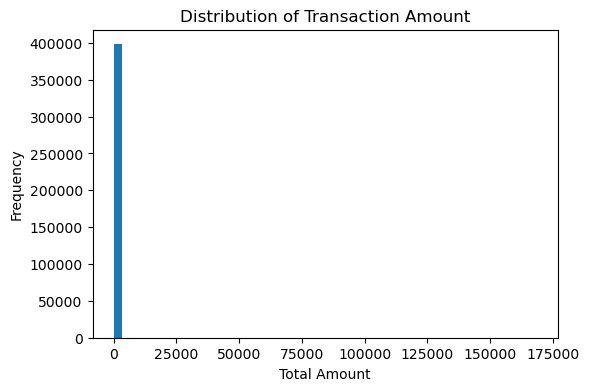

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df["TotalAmount"], bins=50)
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")
plt.show()

In [50]:
country_cols = [col for col in df.columns if col.startswith("Country_")]
print(len(country_cols))

0


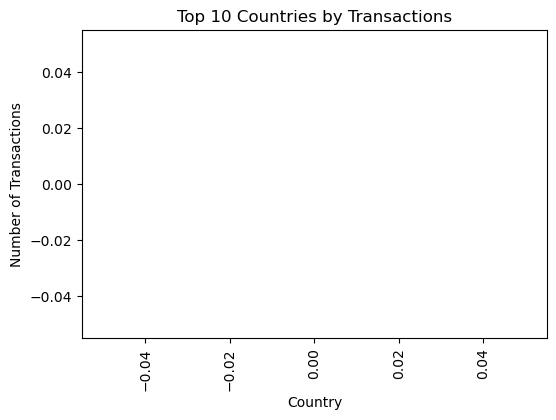

In [51]:
import matplotlib.pyplot as plt
country_cols = [col for col in df.columns if col.startswith("Country_")]
top_countries = (
    df[country_cols]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(6,4))
plt.bar(top_countries.index, top_countries.values)
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.title("Top 10 Countries by Transactions")
plt.xticks(rotation=90)
plt.show()

In [52]:
rfm['HighValueCustomer'].value_counts().plot(
    kind='bar',
    title='High-Value vs Low-Value Customers'
)

<Axes: title={'center': 'High-Value vs Low-Value Customers'}, xlabel='HighValueCustomer'>

In [53]:
# Total customers
total_customers = rfm.shape[0]

# High-value customers
high_value_customers = rfm['HighValueCustomer'].sum()

# Percentage of high-value customers
high_value_percent = round(
    (high_value_customers / total_customers) * 100, 2
)

print("Total Customers:", total_customers)
print("High-Value Customers:", high_value_customers)
print("Percentage of High-Value Customers:", high_value_percent, "%")

Total Customers: 4339
High-Value Customers: 1085
Percentage of High-Value Customers: 25.01 %


## Pie chart 

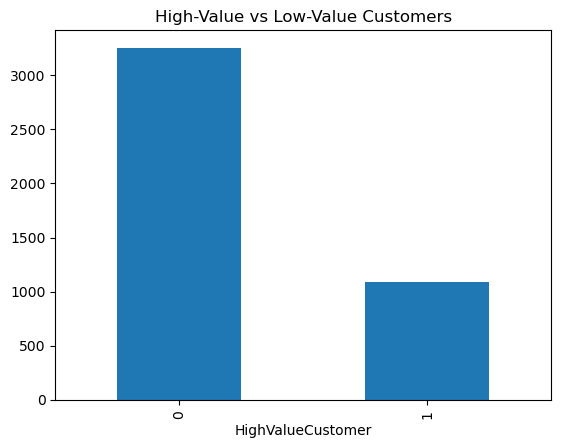

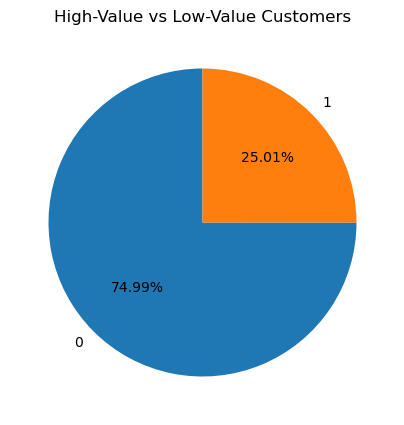

In [54]:
plt.figure(figsize=(5,5))
rfm['HighValueCustomer'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90
)
plt.title("High-Value vs Low-Value Customers")
plt.ylabel("")
plt.show()

##  Analyzing

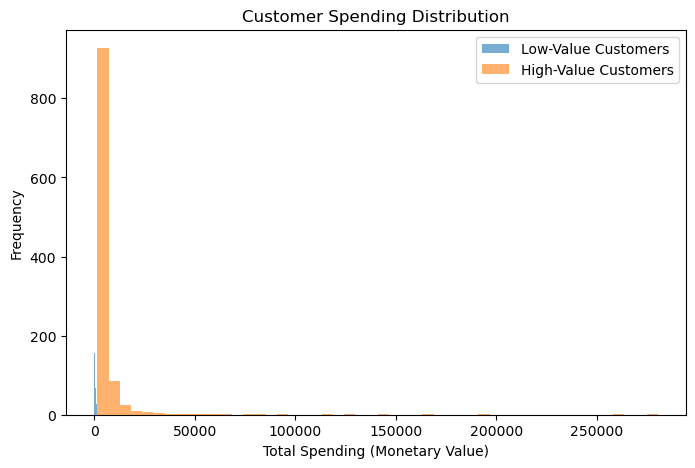

In [55]:
plt.figure(figsize=(8,5))
plt.hist(
    rfm[rfm['HighValueCustomer'] == 0]['Monetary'],
    bins=50,
    alpha=0.6,
    label='Low-Value Customers'
)
plt.hist(
    rfm[rfm['HighValueCustomer'] == 1]['Monetary'],
    bins=50,
    alpha=0.6,
    label='High-Value Customers'
)
plt.legend()
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending (Monetary Value)")
plt.ylabel("Frequency")
plt.show()

## Boxplot of Transaction Amounts 

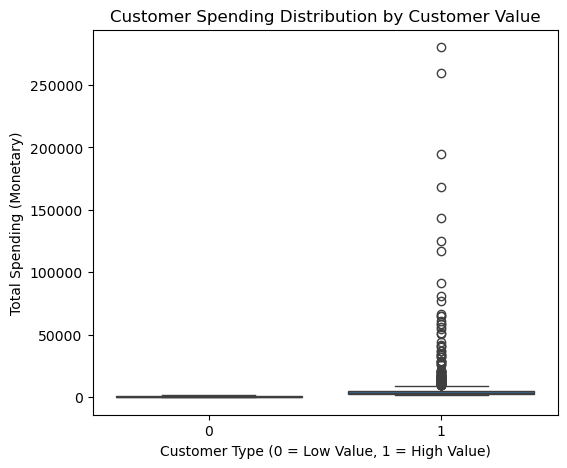

In [56]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x='HighValueCustomer',
    y='Monetary',
    data=rfm
)
plt.title("Customer Spending Distribution by Customer Value")
plt.xlabel("Customer Type (0 = Low Value, 1 = High Value)")
plt.ylabel("Total Spending (Monetary)")
plt.show()

## E-COMMERCE MAPPING

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [58]:
print(rfm.head())
print(rfm.columns)

            Recency  Frequency  Monetary  HighValueCustomer
CustomerID                                                 
12346.0         326          1  77183.60                  1
12347.0           2          7   4310.00                  1
12348.0          75          4   1797.24                  1
12349.0          19          1   1757.55                  1
12350.0         310          1    334.40                  0
Index(['Recency', 'Frequency', 'Monetary', 'HighValueCustomer'], dtype='object')


In [59]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [60]:
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

  File "C:\Users\ajoyb\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ajoyb\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ajoyb\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ajoyb\anaconda3\Lib\subprocess.

In [61]:
print(rfm[['Recency', 'Monetary', 'Cluster']].head())

            Recency  Monetary  Cluster
CustomerID                            
12346.0         326  77183.60        1
12347.0           2   4310.00        0
12348.0          75   1797.24        0
12349.0          19   1757.55        0
12350.0         310    334.40        1


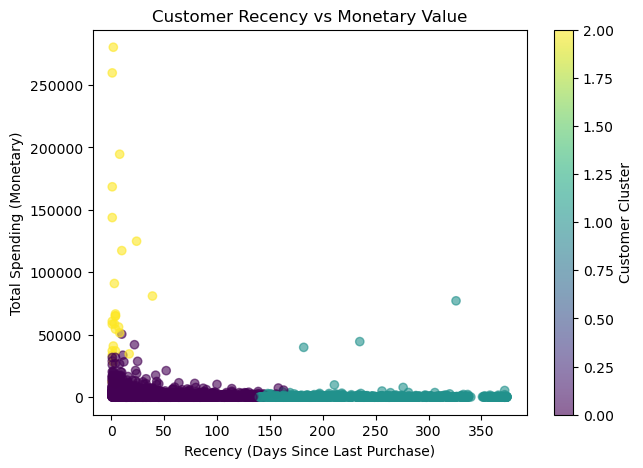

In [62]:
plt.figure(figsize=(7,5))

scatter = plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)
plt.title("Customer Recency vs Monetary Value")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Total Spending (Monetary)")
plt.colorbar(scatter, label="Customer Cluster")
plt.show()

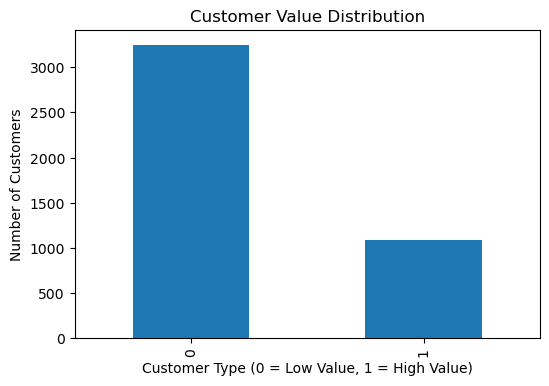

In [63]:
plt.figure(figsize=(6,4))

rfm['HighValueCustomer'].value_counts().plot(kind='bar')

plt.title("Customer Value Distribution")
plt.xlabel("Customer Type (0 = Low Value, 1 = High Value)")
plt.ylabel("Number of Customers")
plt.show()

## High-Value vs Low-Value Customers by Country

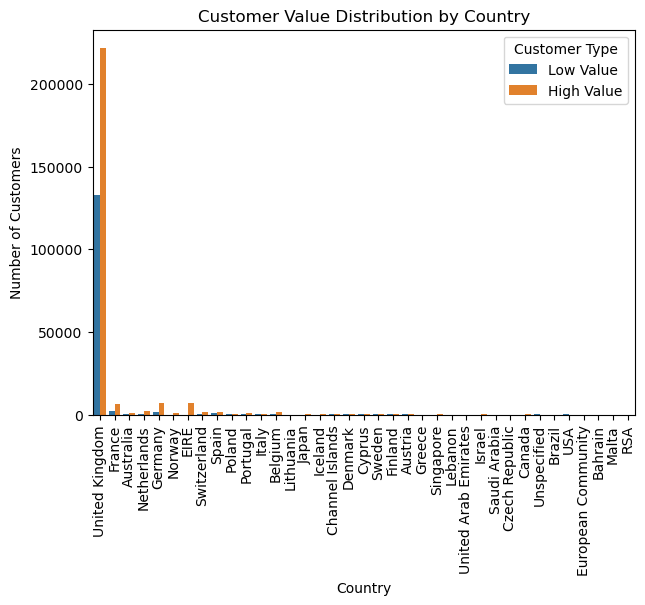

In [64]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Country',
    hue='HighValueCustomer',
    data=df.merge(
        rfm[['HighValueCustomer']],
        left_on='CustomerID',
        right_index=True,
        how='inner'
    )
)

plt.title("Customer Value Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.legend(title="Customer Type", labels=["Low Value", "High Value"])
plt.show()

#### Multivariate Feature Interactions Highlighting

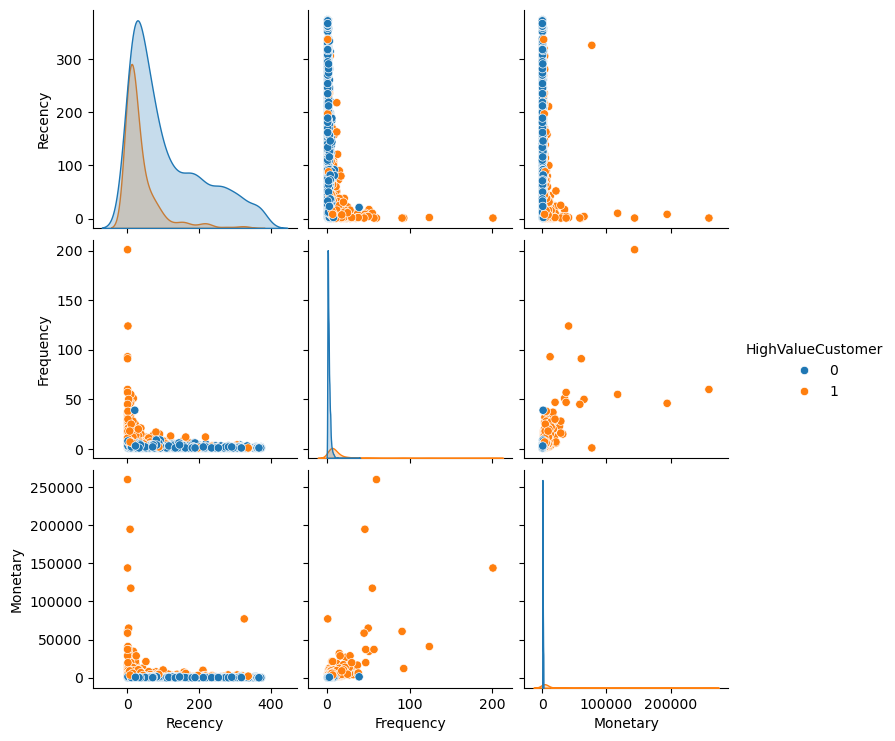

In [65]:
# Take a sample for faster plotting
sample_rfm = rfm[['Recency', 'Frequency', 'Monetary', 'HighValueCustomer']].sample(2000, random_state=42)

sns.pairplot(
    sample_rfm,
    hue='HighValueCustomer',
    diag_kind='kde'
)

plt.show()

In [66]:
corr = rfm[['Recency', 'Frequency', 'Monetary', 'HighValueCustomer']].corr()
corr

,Recency,Frequency,Monetary,HighValueCustomer
Recency,1.000000,-0.260253,-0.122046,-0.326977
Frequency,-0.260253,1.000000,0.554094,0.461974
Monetary,-0.122046,0.554094,1.000000,0.285618
HighValueCustomer,-0.326977,0.461974,0.285618,1.000000


## Compute correlation (E-commerce features)

In [67]:
corr = rfm[['Recency', 'Frequency', 'Monetary', 'HighValueCustomer']].corr()

## Plot heatmap

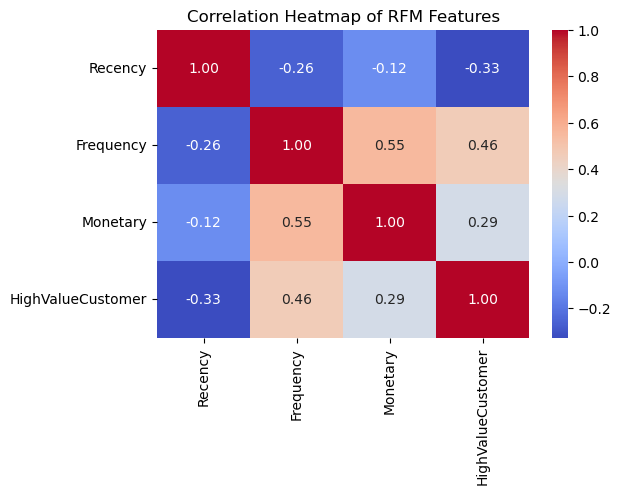

In [68]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of RFM Features")
plt.show()

## RFM Data Calculation

In [69]:
latest_date = df['InvoiceDate'].max()

In [70]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

In [71]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [72]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [74]:
rfm_scaled

array([[ 2.33485829e+00, -3.96512139e-01,  8.35963391e+00],
       [-9.05199314e-01,  3.94687670e-01,  2.51046358e-01],
       [-1.75186336e-01, -2.65374049e-01, -2.85464504e-02],
       ...,
       [-8.45198247e-01, -3.48428173e-01, -2.08712435e-01],
       [-8.85198958e-01,  2.90379646e+00,  4.57171586e-03],
       [-4.95192025e-01, -9.48945321e-02, -2.40912314e-02]])

## Elbow Method

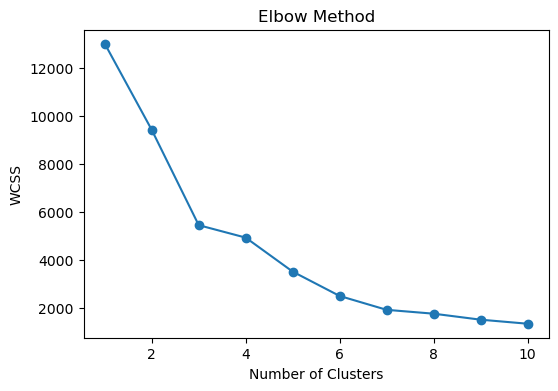

In [75]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Apply K-Means Clustering

## Customer Segmentation Using K-Means


## Model Selection

Multiple clustering algorithms were evaluated for customer segmentation. 
K-Means clustering provided clear and interpretable customer segments, 
while Hierarchical Clustering was used for comparison. 
K-Means was selected as the final segmentation model due to its scalability 
and better cluster separation.

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
kmeans = KMeans(n_clusters=4)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [77]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,0
12347.0,1,182,4310.00,1
12348.0,74,31,1797.24,1
12349.0,18,73,1757.55,1
12350.0,309,17,334.40,0


In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
sil_score = silhouette_score(rfm_scaled, rfm['Cluster'])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.6020142101419289


## Cluster Visualization


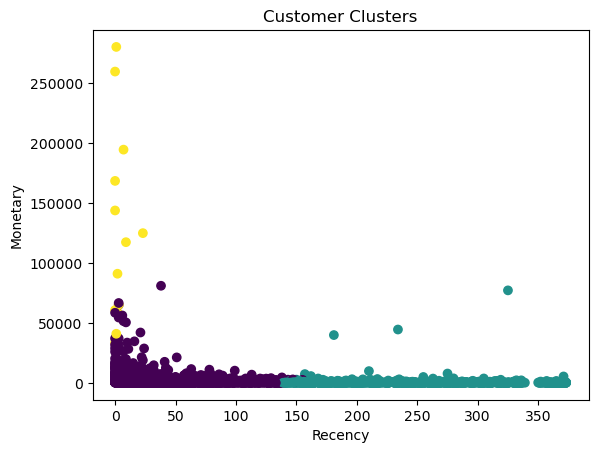

In [79]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Clusters")
plt.show()

## Check Cluster Meaning

In [80]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,40.368762,103.066235,2028.208836
1,246.308333,27.789815,637.318510
2,3.692308,2566.000000,126118.310000


In [81]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=4)
rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)
rfm.groupby('HC_Cluster').mean()

,Recency,Frequency,Monetary,Cluster
HC_Cluster,,,,
0,40.555419,103.148707,2105.238197,0.008621
1,6.000000,847.142857,176606.164286,2.000000
2,245.674074,31.237037,512.638834,0.977778
3,1.000000,5807.750000,70925.287500,2.000000


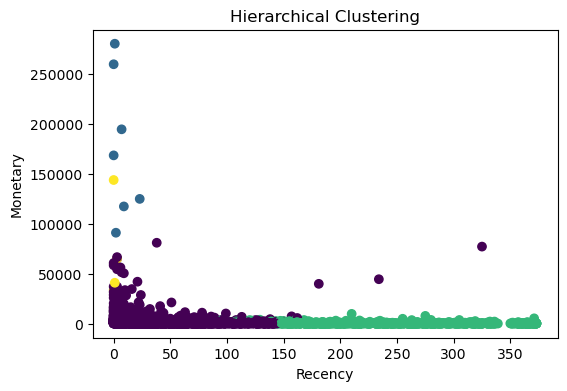

In [82]:
plt.figure(figsize=(6,4))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['HC_Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Hierarchical Clustering")
plt.show()

## Create Target Column (Prediction)

In [83]:
rfm['HighValueCustomer'] = 0
rfm.loc[rfm['Monetary'] > rfm['Monetary'].median(), 'HighValueCustomer'] = 1

In [84]:
rfm

,Recency,Frequency,Monetary,Cluster,HC_Cluster,HighValueCustomer
CustomerID,,,,,,
12346.0,325,1,77183.60,1,0,1
12347.0,1,182,4310.00,0,0,1
12348.0,74,31,1797.24,0,0,1
12349.0,18,73,1757.55,0,0,1
12350.0,309,17,334.40,1,2,0
...,...,...,...,...,...,...
18280.0,277,10,180.60,1,2,0
18281.0,180,7,80.82,1,2,0
18282.0,7,12,178.05,0,0,0


In [85]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,HC_Cluster,HighValueCustomer
CustomerID,,,,,,
12346.0,325,1,77183.60,1,0,1
12347.0,1,182,4310.00,0,0,1
12348.0,74,31,1797.24,0,0,1
12349.0,18,73,1757.55,0,0,1
12350.0,309,17,334.40,1,2,0


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['HighValueCustomer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)
accuracy_score(y_test, model.predict(X_test))

0.9988479262672811

## Train Test Split

In [87]:
from sklearn.model_selection import train_test_split
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [88]:
X

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [89]:
y

CustomerID
12346.0    1
12347.0    1
12348.0    1
12349.0    1
12350.0    0
          ..
18280.0    0
18281.0    0
18282.0    0
18283.0    1
18287.0    1
Name: HighValueCustomer, Length: 4339, dtype: int64

In [90]:
from sklearn.model_selection import train_test_split
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [91]:
X

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [92]:
y

CustomerID
12346.0    1
12347.0    1
12348.0    1
12349.0    1
12350.0    0
          ..
18280.0    0
18281.0    0
18282.0    0
18283.0    1
18287.0    1
Name: HighValueCustomer, Length: 4339, dtype: int64

<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 7 Random Forest Classifier Building</p>


## Random Forest

## Feature Engineering and Importance

RFM features were used to capture customer purchasing behavior. 
Monetary value was found to be the most important feature in identifying 
high-value customers, followed by frequency and recency.


In [93]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [94]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_accuracy

1.0

In [95]:
y_pred = model.predict(X_test)

In [96]:
y_pred

array([0, 0, 0, ..., 0, 1, 1])

In [97]:
X_test

,Recency,Frequency,Monetary
CustomerID,,,
17620.0,59,4,81.44
14924.0,245,10,310.05
13504.0,63,22,295.93
15149.0,133,23,520.80
15260.0,99,77,1810.77
...,...,...,...
18169.0,60,9,202.65
12374.0,24,33,742.93
12851.0,96,50,135.18


In [98]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_test, y_pred)

1.0

In [99]:
y_test

CustomerID
17620.0    0
14924.0    0
13504.0    0
15149.0    0
15260.0    1
          ..
18169.0    0
12374.0    1
12851.0    0
14923.0    1
13165.0    1
Name: HighValueCustomer, Length: 1302, dtype: int64

In [100]:
y_pred

array([0, 0, 0, ..., 0, 1, 1])

In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       1.00      1.00      1.00       651

    accuracy                           1.00      1302
   macro avg       1.00      1.00      1.00      1302
weighted avg       1.00      1.00      1.00      1302



## IMPORTING THE LIBRAIES AND TRAIN AND TEST THE X AND Y VALUES

In [102]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [103]:
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)  

In [104]:
X_test_scaled

array([[ 0.48417861, -0.43780547, -0.17304567],
       [ 1.94444918, -0.31856949, -0.13914974],
       [-0.76889141,  1.40041583,  0.5746457 ],
       ...,
       [-0.32489022,  0.51111418, -0.16481324],
       [-0.26569006,  0.10372459, -0.0412884 ],
       [-0.52222408,  0.43162353, -0.13030951]])

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [106]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [108]:
rf_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [109]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf', RandomForestClassifier(random_state=42))])

In [110]:
y_pred_rf = rf_pipeline.predict(X_test)

In [111]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9988479262672811


##  Confusion Matrix for Random Forest

In [112]:
from sklearn.metrics import confusion_matrix

In [113]:
rf_preds = rf_pipeline.predict(X_test)

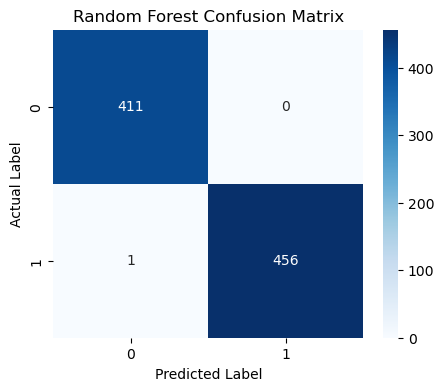

In [114]:
plt.figure(figsize=(5,4))

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [115]:
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 8 Logistic Regression Classifier Building</p>


## Logistic Regression

In [116]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,HC_Cluster,HighValueCustomer
CustomerID,,,,,,
12346.0,325,1,77183.60,1,0,1
12347.0,1,182,4310.00,0,0,1
12348.0,74,31,1797.24,0,0,1
12349.0,18,73,1757.55,0,0,1
12350.0,309,17,334.40,1,2,0


In [117]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.9988479262672811

In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [121]:
numeric_features = ['Recency', 'Frequency', 'Monetary']
categorical_features = []  # No categorical features used in RFM modeling

In [122]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [123]:
print("Preprocessing setup complete.")

Preprocessing setup complete.


## LOGISTIC REGRESSION PIPELINE

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [125]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_features = ['Recency', 'Frequency', 'Monetary']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [128]:
lr_pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [129]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Recency', 'Frequency',
                                                   'Monetary'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [130]:
lr_preds = lr_pipeline.predict(X_test)

In [131]:
lr_accuracy = accuracy_score(y_test, lr_preds)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9331797235023042


In [132]:
from sklearn.metrics import accuracy_score, classification_report

In [133]:
lr_preds = lr_pipeline.predict(X_test)

In [134]:
print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))


--- Logistic Regression Results ---
Accuracy: 0.9331797235023042

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       411
           1       0.97      0.90      0.93       457

    accuracy                           0.93       868
   macro avg       0.93      0.93      0.93       868
weighted avg       0.94      0.93      0.93       868



In [135]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
lr_preds = lr_pipeline.predict(X_test)

In [137]:
lr_cm = confusion_matrix(y_test, lr_preds)

In [138]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Low Value', 'High Value'],
        yticklabels=['Low Value', 'High Value']
    )
    plt.title(f'{model_name} Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

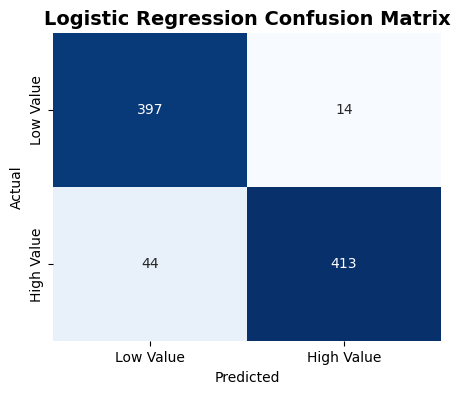

In [139]:
plot_confusion_matrix(lr_cm, "Logistic Regression")

In [140]:
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_preds)

<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 9 Model Comparison Classifier Building</p>


## MODEL COMPARISON

In [141]:
import pandas as pd
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy]
})
model_comparison

,Model,Accuracy
0,Logistic Regression,0.933180
1,Random Forest,0.998848


## Confusion Matrix

In [142]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [143]:
y_pred=model.predict(X_test_scaled)

In [144]:
print("accuracy:",accuracy_score(y_test,y_pred))
print("\nclassification report:\n",classification_report(y_test,y_pred))
print("\nconfusion matrix:\n",confusion_matrix(y_test,y_pred))

accuracy: 0.4735023041474654

classification report:
               precision    recall  f1-score   support

           0       0.47      1.00      0.64       411
           1       0.00      0.00      0.00       457

    accuracy                           0.47       868
   macro avg       0.24      0.50      0.32       868
weighted avg       0.22      0.47      0.30       868


confusion matrix:
 [[411   0]
 [457   0]]


In [145]:
df = pd.read_csv("capston project data.csv", encoding="ISO-8859-1")
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
df = pd.get_dummies(df, columns=["Country"], drop_first=True)

In [146]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalAmount,Country_Austria,Country_Bahrain,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,15.30,False,False,...,False,False,False,False,False,False,False,False,True,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,True,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,22.00,False,False,...,False,False,False,False,False,False,False,False,True,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,True,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,20.34,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,10.20,False,False,...,False,False,False,False,False,False,False,False,False,False
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,12.60,False,False,...,False,False,False,False,False,False,False,False,False,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,16.60,False,False,...,False,False,False,False,False,False,False,False,False,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,16.60,False,False,...,False,False,False,False,False,False,False,False,False,False


<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;"> XGBOOST PIPELINE</p>



In [147]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']

In [149]:
numeric_features = ['Recency', 'Frequency', 'Monetary']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [150]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [151]:
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gb_model)
])

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [153]:
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Recency', 'Frequency',
                                                   'Monetary'])])),
                ('classifier',
                 GradientBoostingClassifier(n_estimators=300,
                                            random_state=42))])

In [154]:
y_pred = clf_pipeline.predict(X_test)

In [155]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       1.00      1.00      1.00       651

    accuracy                           1.00      1302
   macro avg       1.00      1.00      1.00      1302
weighted avg       1.00      1.00      1.00      1302



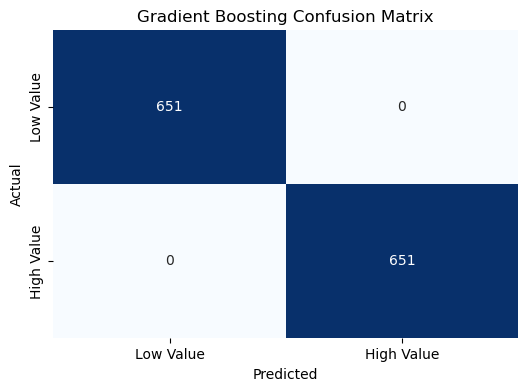

In [156]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Low Value", "High Value"],
    yticklabels=["Low Value", "High Value"]
)
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [157]:
gb_preds = clf_pipeline.predict(X_test)

In [158]:
from sklearn.metrics import accuracy_score
gb_accuracy = accuracy_score(y_test, gb_preds)
gb_accuracy

1.0

In [159]:
clf_pipeline.fit(X_train, y_train)   # this is Gradient Boosting
gb_preds = clf_pipeline.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_preds)

<a id="preprocessing"></a>
# <p style="background-color:black; font-family:calibri; color:pink; font-size:150%; text-align:center; border-radius:15px 50px;">Step 10 Conclusion</p>


## Conclution

<div style="background-color: #2c3e50; font-family: calibri; color: white; font-size: 115%; padding: 20px; border-radius: 10px;">
  
  <strong>Best Performing Models:</strong>
  <br><br>

  <strong>Gradient Boosting</strong> demonstrated the best overall performance among the evaluated models,
  achieving the highest accuracy and balanced precision–recall scores for identifying high-value customers.
  <br><br>

  <strong>Random Forest</strong> also performed strongly and showed robust results, making it a reliable model
  for customer value prediction.
  <br><br>

  <strong>Logistic Regression</strong> performed comparatively lower but still provided meaningful insights
  and served as a good baseline model.
  <br><br>

  Overall, ensemble-based models such as <strong>Gradient Boosting</strong> and <strong>Random Forest</strong>
  are the most suitable choices for predicting high-value customers in an e-commerce setting.
  The project successfully segments customers and predicts their segment class, enabling businesses to take data-driven marketing decisions.
</div>


## Actionable Business Recommendations

- High-value customers should be targeted with loyalty programs and exclusive offers.
- At-risk customers can be re-engaged through personalized discounts and reminders.
- New customers should receive onboarding promotions to encourage repeat purchases.
- Marketing strategies should focus on high-frequency and high-monetary segments.


## Model Comparison and Selection

Two machine learning models were used to predict high-value customers: 
Logistic Regression and Random Forest. After comparing their accuracy, 
Random Forest performed better and was selected as the final model for prediction.


In [160]:
results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [gb_accuracy, rf_accuracy, lr_accuracy]
})

results = results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Gradient Boosting,1.000000
1,Random Forest,0.998848
2,Logistic Regression,0.933180


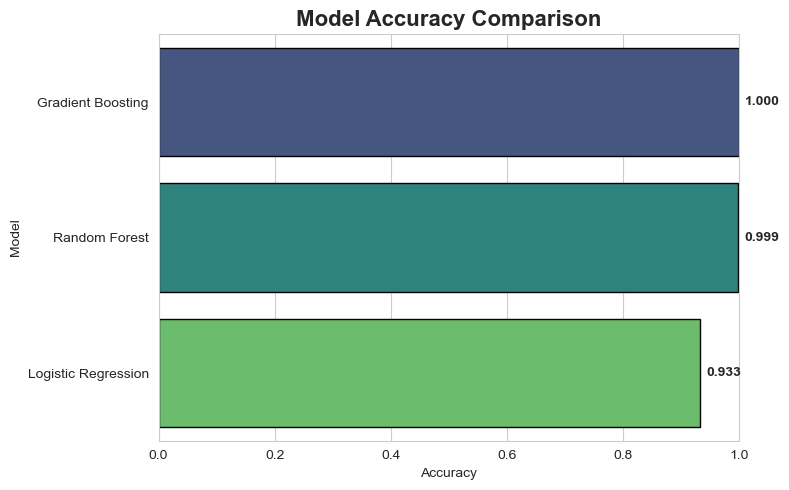

In [161]:
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results,
    palette='viridis',
    edgecolor='black'
)

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)

for index, value in enumerate(results['Accuracy']):
    plt.text(value + 0.01, index, f"{value:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [162]:
import joblib

# Save Logistic Regression model
joblib.dump(lr_pipeline, "logistic_regression_model.pkl")

# Save Random Forest model
joblib.dump(rf_pipeline, "random_forest_model.pkl")

# Save Gradient Boosting model
joblib.dump(clf_pipeline, "gradient_boosting_model.pkl")

print("✅ Models saved successfully using joblib")

✅ Models saved successfully using joblib


In [163]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

In [164]:
# ===============================
# MODEL TRAINING & EVALUATION
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# -------------------------------
# Features & Target
# -------------------------------
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['HighValueCustomer']

# -------------------------------
# Train-Test Split (ONLY ONCE)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------------
# Scaling
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Models
# -------------------------------
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# -------------------------------
# Train Models
# -------------------------------
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)

# -------------------------------
# Predictions
# -------------------------------
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)
gb_preds = gb_model.predict(X_test_scaled)

# -------------------------------
# Metrics Table (NO ERRORS)
# -------------------------------
model_metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, gb_preds)
    ],
    "Precision": [
        precision_score(y_test, lr_preds),
        precision_score(y_test, rf_preds),
        precision_score(y_test, gb_preds)
    ],
    "Recall": [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, gb_preds)
    ],
    "F1-Score": [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, gb_preds)
    ]
})

# -------------------------------
# Display Results
# -------------------------------
model_metrics

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.908986,0.933985,0.880184,0.906287
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Gradient Boosting,1.000000,1.000000,1.000000,1.000000


In [165]:
results = pd.DataFrame(
    model_metrics,
    index=[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ]
)

In [166]:
final_table = results.sort_values(
    by="F1-Score",
    ascending=False
).T

In [167]:
print("Model Comparison Table:")
display(final_table)

Model Comparison Table:


,Logistic Regression,Random Forest,Gradient Boosting
Model,NaN,NaN,NaN
Accuracy,NaN,NaN,NaN
Precision,NaN,NaN,NaN
Recall,NaN,NaN,NaN
F1-Score,NaN,NaN,NaN
